# Digit Classification using CNN
Dataset: MNIST

In [22]:
# python version and pytorch version
import sys
print(sys.version_info)
import torch
print(torch.__version__)

sys.version_info(major=3, minor=11, micro=9, releaselevel='final', serial=0)
2.6.0+cpu


In [23]:
# Loading and preprocessing dataset
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms

import torch
from torch.utils.data import DataLoader

batch_size = 60
train_dataset = datasets.MNIST(root="dataset/", download=True, train=True, transform=transforms.ToTensor())
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = datasets.MNIST(root="dataset/", download=True, train=False, transform=transforms.ToTensor())
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)


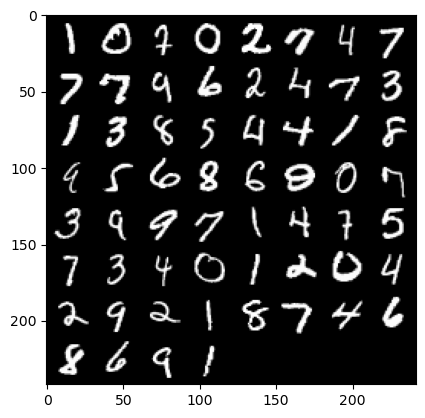

In [24]:
# let's see how a randome batch of data looks like
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
labels
# show images
imshow(torchvision.utils.make_grid(images))


In [25]:
# CNN architecture
from torch import nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        """
        Building blocks of convolutional neural network
        Parameters:
        * in_channels: number of channels in the input image (for grasy scale image, it's 1)
        * num_classes: number of output classes (for MNIST, it's 10)
        """
        super(CNN,self).__init__()

        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(16*7*7, num_classes)

    def forward(self, x):
        """
        Define the forward pass of the neural network
        Parameters:
            x: Input tensor

        Returns:
            torch.Tensor: Output tensor after passing through the network
        """
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fc1(x)
        return x


In [26]:
# create our model and move it to the device where it will be trained and run
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
model = CNN(in_channels=1, num_classes=10).to(device)
print(model)

Device: cpu
CNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=784, out_features=10, bias=True)
)


In [27]:
# training the model
from tqdm import tqdm
from torch import optim

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
for epoch in range(num_epochs):
    print(f"Epoch [{epoch+1}/{num_epochs}]")

    for batch_index, (data, targets) in enumerate(tqdm(train_loader)):
        data = data.to(device)
        targets = targets.to(device)
        scores = model(data)
        loss = criterion(scores, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


Epoch [1/5]


100%|██████████| 1000/1000 [00:06<00:00, 143.86it/s]


Epoch [2/5]


100%|██████████| 1000/1000 [00:07<00:00, 130.01it/s]


Epoch [3/5]


100%|██████████| 1000/1000 [00:06<00:00, 148.60it/s]


Epoch [4/5]


100%|██████████| 1000/1000 [00:06<00:00, 145.60it/s]


Epoch [5/5]


100%|██████████| 1000/1000 [00:07<00:00, 138.76it/s]


In [28]:
# Evaluate the model
# Set up of muticlass accuracy metric
import torchmetrics
from torchmetrics import Accuracy, Precision, Recall

acc = Accuracy(task="multiclass", num_classes=10)
model.eval()
with torch.no_grad():
    for images,labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        acc(preds, labels)

test_accuracy = acc.compute()
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Accuracy: 0.9850


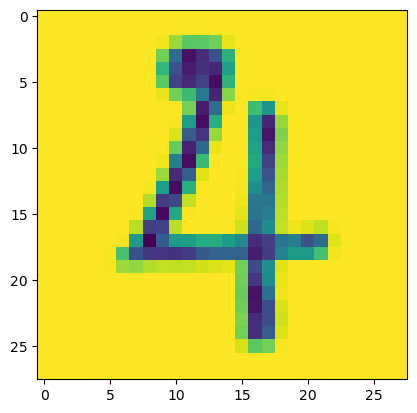

Predicted number: 3


In [39]:
# Test on my owe image
from PIL import Image
img = Image.open("imgs/number_4.png").convert("L")
# apply same transfomation as the training data
transfrom = transforms.Compose([
    transforms.Resize((28,28)),
    transforms.ToTensor()
])

img_tensor = transfrom(img)
imshow(img_tensor)

img_tensor = img_tensor.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(img_tensor)
    _, pred = torch.max(output, 1)
    print(f"Predicted number: {pred.item()}")